# Neural Network Classifier -- Urdu News Article Classifier
**Project:** Multi-class classification of Urdu news into 5 categories  
**Dataset:** 1140 articles | Sources: Express, Geo, Jang  
**Categories:** Business, Entertainment, Science and Technology, Sports, World  

3-layer MLP built with **PyTorch**, with SMOTE oversampling and dynamic learning-rate scheduling.

## 1. Imports and Configuration

In [7]:
import pandas as pd
import numpy as np
!pip3 install imbalanced-learn --break-system-packages
import re
import matplotlib.pyplot as plt
import seaborn as sns
from urduhack import stop_words
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# -- Constants --
DATA_PATH = "../data/combined_file.csv"
TEST_SIZE = 0.2
RANDOM_STATE = 505
SMOTE_RANDOM_STATE = 16
LOWER_PCT = 2.5
UPPER_PCT = 97.5

TITLE_MAX_FEATURES = 10_000
CONTENT_MAX_FEATURES = 20_000

BATCH_SIZE = 16
EPOCHS = 20
LR = 1e-3
DROPOUT = 0.7
PATIENCE = 3

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cpu


## 2. Data Loading and EDA

In [8]:
articles = pd.read_csv(DATA_PATH)
articles['content'] = articles['content'].astype(str).fillna('')
articles['title'] = articles['title'].astype(str).fillna('')

print(f"Dataset shape: {articles.shape}")
print(f"\nMissing values:\n{articles.isnull().sum()}")
print(f"\nCategory distribution:\n{articles['gold_label'].value_counts()}")
articles.head()

Dataset shape: (1193, 5)

Missing values:
id            0
title         0
link          0
content       0
gold_label    0
dtype: int64

Category distribution:
gold_label
science-technology    240
world                 240
entertainment         239
sports                238
business              236
Name: count, dtype: int64


,id,title,link,content,gold_label
0,0,سلمان کے بعد شاہ رخ خان کو بھی جان سے مارنےکی ...,https://urdu.geo.tv/latest/385991-,ممبئی: بالی وڈ اداکار سلمان خان کے بعد اب کنگ...,entertainment
1,1,طلاق کی خبروں کے باوجود ابھیشیک اور ایشوریا کو...,https://urdu.geo.tv/latest/385972-,بالی وڈ کی معروف جوڑی ایشوریا رائے اور ابھیشیک...,entertainment
2,2,'میرا اپنا دماغ خراب تھا'، نادیہ خان نے کم عمر...,https://urdu.geo.tv/latest/385943-,پاکستان شوبز انڈسٹری کی معروف میزبان و اداکارہ...,entertainment
3,3,امیتابھ نہ شاہ رخ، بالی وڈ میں سب سے پہلے رولز...,https://urdu.geo.tv/latest/385850-,رولز رائس کا شمار لگژری اور مہنگی ترین گاڑیوں ...,entertainment
4,4,ہنی سنگھ کی پاکستانی گلوکار کو کریڈٹ دیکر سرا...,https://urdu.geo.tv/latest/385820-,بالی وڈ میں پاکستانی گانوں کو ہمیشہ ہی پسند کی...,entertainment


## 3. Preprocessing and Outlier Removal

In [9]:
def clean_text(text: str) -> str:
    """Remove punctuation, digits, and Urdu stopwords."""
    sw = stop_words.STOP_WORDS
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    return " ".join(w for w in text.split() if w not in sw)

articles['cleaned_content'] = articles['content'].apply(clean_text)
articles['cleaned_title'] = articles['title'].apply(clean_text)
articles['combined_text'] = articles['cleaned_title'] + ' ' + articles['cleaned_content']
articles['content_length'] = articles['cleaned_content'].apply(len)

# Remove outliers by content length
lo = articles['content_length'].quantile(LOWER_PCT / 100)
hi = articles['content_length'].quantile(UPPER_PCT / 100)
filtered = articles[(articles['content_length'] >= lo) & (articles['content_length'] <= hi)].copy()

print(f"Original: {len(articles)}  |  After outlier removal: {len(filtered)}")

Original: 1193  |  After outlier removal: 1133


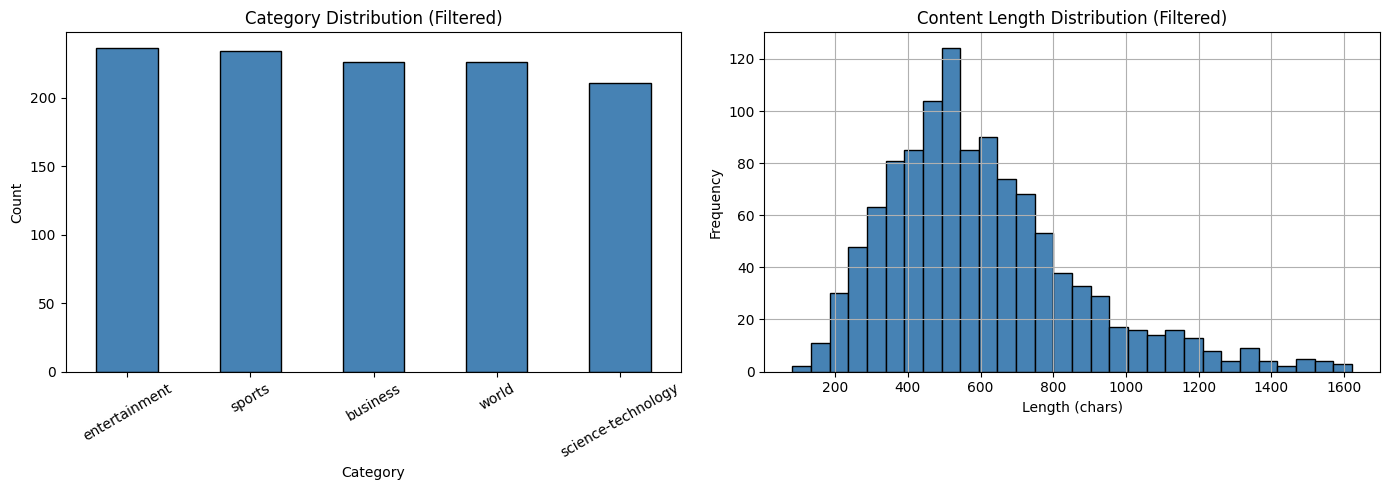

In [10]:
# -- EDA plots --
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

filtered['gold_label'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Category Distribution (Filtered)')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

filtered['content_length'].hist(bins=30, ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Content Length Distribution (Filtered)')
axes[1].set_xlabel('Length (chars)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
# plt.savefig('nn_distribution.png', dpi=150)
plt.show()

## 4. Vectorization, SMOTE and Class Weights

In [11]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(filtered['gold_label'])

# Split before vectorizing to prevent data leakage
(
    X_train_title_raw, X_test_title_raw,
    X_train_content_raw, X_test_content_raw,
    y_train, y_test,
) = train_test_split(
    filtered['cleaned_title'],
    filtered['cleaned_content'],
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

# TF-IDF vectorisation (separate for title and content)
vec_title = TfidfVectorizer(max_features=TITLE_MAX_FEATURES, ngram_range=(1, 2), sublinear_tf=True)
vec_content = TfidfVectorizer(max_features=CONTENT_MAX_FEATURES, ngram_range=(1, 2), sublinear_tf=True)

X_train_title = vec_title.fit_transform(X_train_title_raw).toarray()
X_test_title = vec_title.transform(X_test_title_raw).toarray()

X_train_content = vec_content.fit_transform(X_train_content_raw).toarray()
X_test_content = vec_content.transform(X_test_content_raw).toarray()

# Merge title + content features
X_train = np.hstack([X_train_title, X_train_content])
X_test = np.hstack([X_test_title, X_test_content])

print(f"Feature matrix: train={X_train.shape}  |  test={X_test.shape}")

Feature matrix: train=(906, 27636)  |  test=(227, 27636)


In [12]:
# SMOTE oversampling on training set
smote = SMOTE(random_state=SMOTE_RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"After SMOTE: {X_train_res.shape}")

# Class weights for loss function
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_res),
    y=y_train_res,
)
print(f"Class weights: {dict(enumerate(class_weights))}")

After SMOTE: (960, 27636)
Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0)}


## 5. PyTorch Dataset and DataLoader

In [13]:
def make_tensors(X: np.ndarray, y: np.ndarray):
    return (
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long),
    )

X_tr_t, y_tr_t = make_tensors(X_train_res, y_train_res)
X_te_t, y_te_t = make_tensors(X_test, y_test)

train_loader = DataLoader(
    TensorDataset(X_tr_t, y_tr_t),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

print(f"Training batches per epoch: {len(train_loader)}")

Training batches per epoch: 60


## 6. Model Definition

In [14]:
class UrduNewsClassifier(nn.Module):
    """3-layer MLP for multi-class text classification."""

    def __init__(self, input_dim: int, n_classes: int, dropout: float = DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


N_CLASSES = len(label_encoder.classes_)
model = UrduNewsClassifier(X_tr_t.shape[1], N_CLASSES).to(DEVICE)
print(model)

UrduNewsClassifier(
  (net): Sequential(
    (0): Linear(in_features=27636, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.7, inplace=False)
    (3): Linear(in_features=512, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.7, inplace=False)
    (6): Linear(in_features=128, out_features=5, bias=True)
  )
)


## 7. Training

In [15]:
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=PATIENCE
)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

X_val_t, y_val_t = X_te_t.to(DEVICE), y_te_t.to(DEVICE)   # use test set as val here

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * len(y_batch)
        correct += (logits.argmax(1) == y_batch).sum().item()
        total += len(y_batch)

    train_loss = running_loss / total
    train_acc = correct / total

    # Validation
    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_t)
        val_loss = criterion(val_logits, y_val_t).item()
        val_acc = (val_logits.argmax(1) == y_val_t).float().mean().item()

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if epoch % 5 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:>3}/{EPOCHS} | "
            f"train loss={train_loss:.4f} acc={train_acc:.3f} | "
            f"val loss={val_loss:.4f} acc={val_acc:.3f}"
        )

Epoch   1/20 | train loss=1.5469 acc=0.447 | val loss=1.2888 acc=0.872
Epoch   5/20 | train loss=0.1185 acc=0.963 | val loss=0.3775 acc=0.912
Epoch  10/20 | train loss=0.0939 acc=0.972 | val loss=0.4154 acc=0.930
Epoch  15/20 | train loss=0.0562 acc=0.975 | val loss=0.4405 acc=0.930
Epoch  20/20 | train loss=0.0659 acc=0.976 | val loss=0.4472 acc=0.930


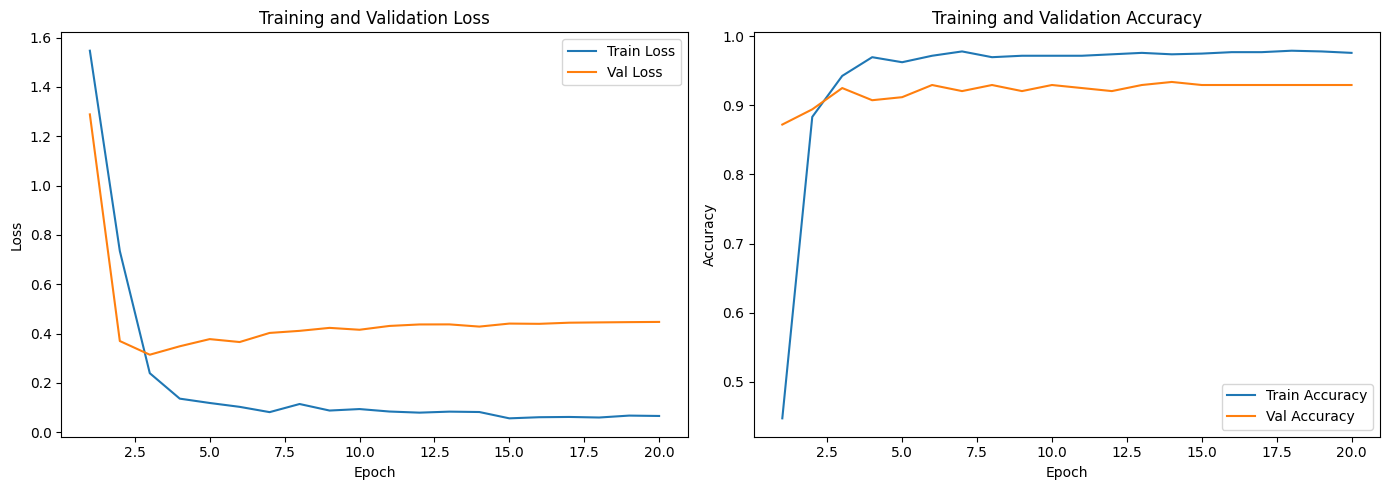

In [16]:
# -- Learning curves --
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history['train_loss'], label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'], label='Val Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs_range, history['train_acc'], label='Train Accuracy')
axes[1].plot(epochs_range, history['val_acc'], label='Val Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
# plt.savefig('nn_learning_curves.png', dpi=150)
plt.show()

## 8. Evaluation

In [17]:
model.eval()
with torch.no_grad():
    logits = model(X_te_t.to(DEVICE))
    y_pred = logits.argmax(1).cpu().numpy()

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Accuracy: 0.9295

Classification Report:
                    precision    recall  f1-score   support

          business       0.96      0.96      0.96        48
     entertainment       0.93      0.98      0.95        52
science-technology       0.81      0.83      0.82        41
            sports       0.97      0.88      0.93        42
             world       0.98      0.98      0.98        44

          accuracy                           0.93       227
         macro avg       0.93      0.93      0.93       227
      weighted avg       0.93      0.93      0.93       227



## 9. Confusion Matrix

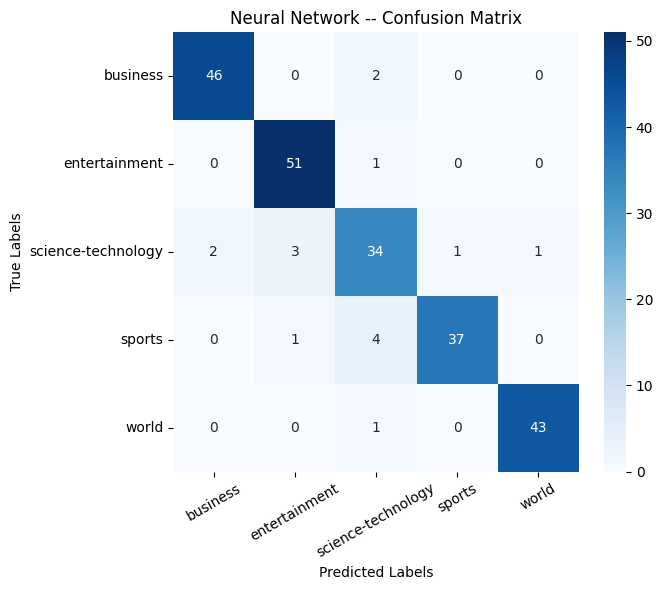

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
)
plt.title('Neural Network -- Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(rotation=30)
plt.tight_layout()
# plt.savefig('nn_confusion_matrix.png', dpi=150)
plt.show()